In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

%matplotlib inline

In [9]:
fund_master = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/01_fund_master.csv")

nav_history = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/02_nav_history.csv")

aum = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/03_aum_by_fund_house.csv")

sip = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/04_monthly_sip_inflows.csv")

category = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/05_category_inflows.csv")

folio = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/06_industry_folio_count.csv")

performance = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/07_scheme_performance.csv")

transactions = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/08_investor_transactions.csv")

portfolio = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/09_portfolio_holdings.csv")

benchmark = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/10_benchmark_indices.csv")

In [10]:
print(fund_master.shape)
print(nav_history.shape)
print(transactions.shape)
print(performance.shape)

(40, 15)
(46000, 3)
(32778, 13)
(40, 19)


# NAV Trend Analysis

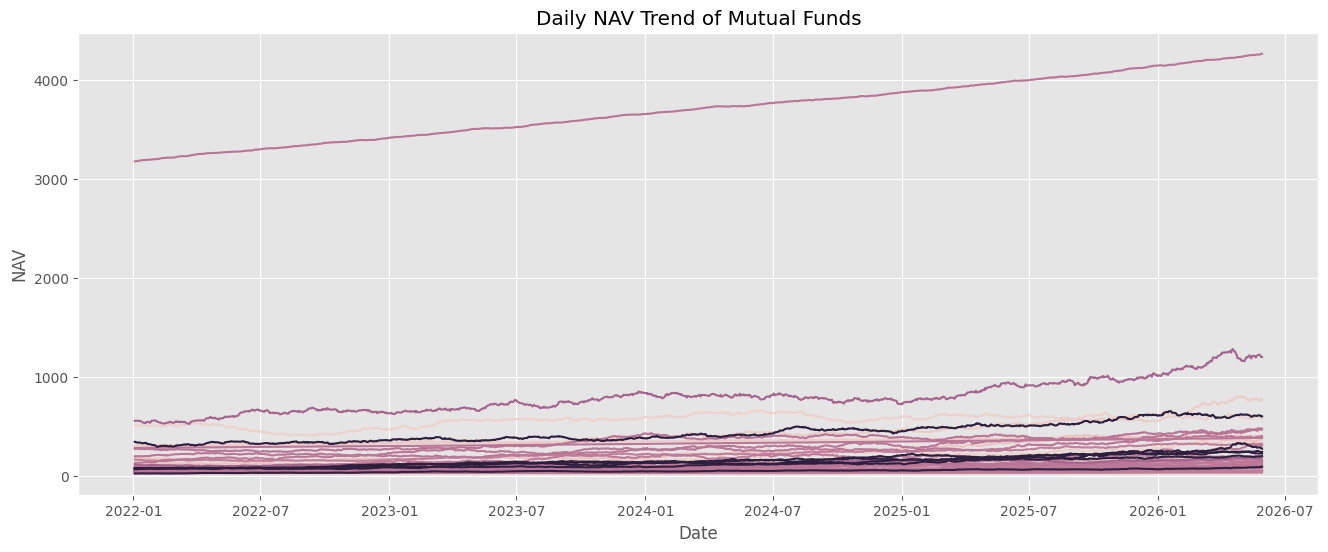

In [11]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

plt.figure(figsize=(16,6))
sns.lineplot(
    data=nav_history,
    x="date",
    y="nav",
    hue="amfi_code",
    legend=False
)
plt.title("Daily NAV Trend of Mutual Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

# AUM Growth by Fund House

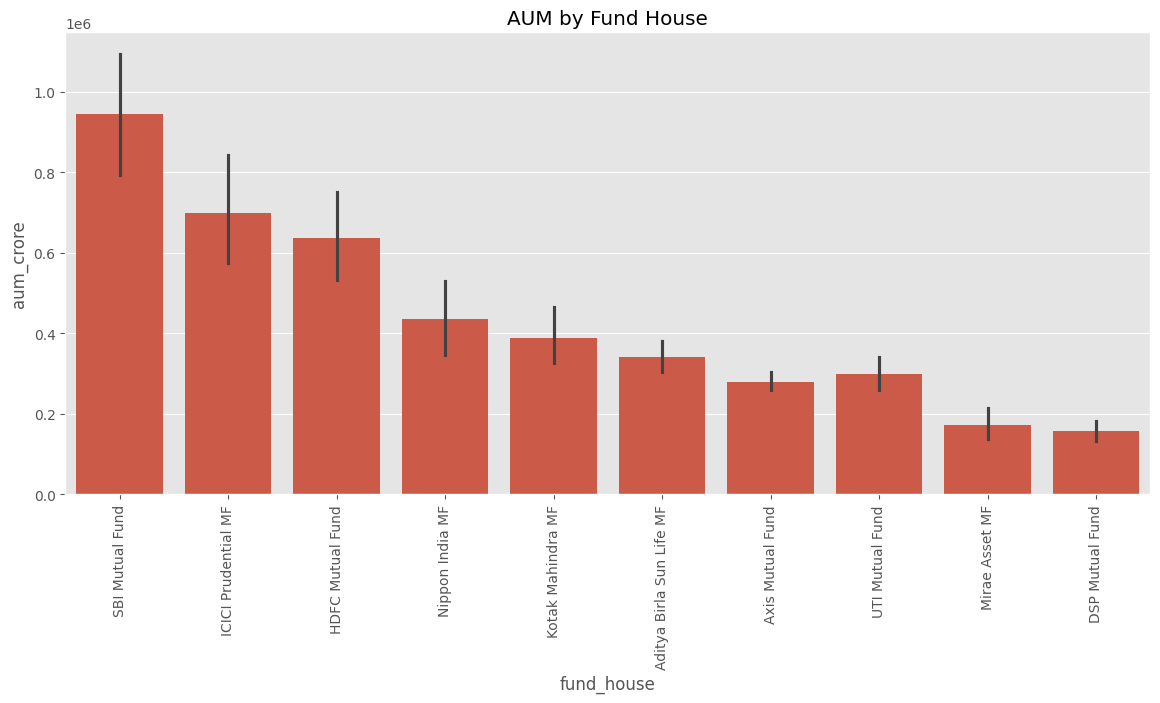

In [13]:
plt.figure(figsize=(14,6))
sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=90)
plt.title("AUM by Fund House")
plt.show()

# SIP Inflow Trend

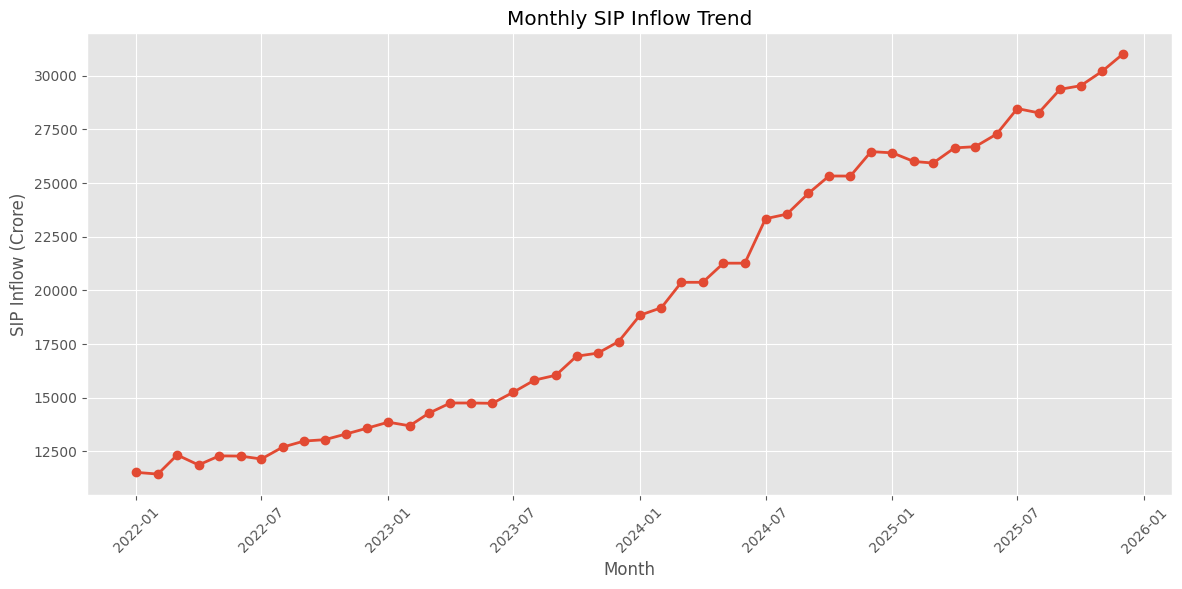

In [14]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(14,6))
plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Category-wise Inflow

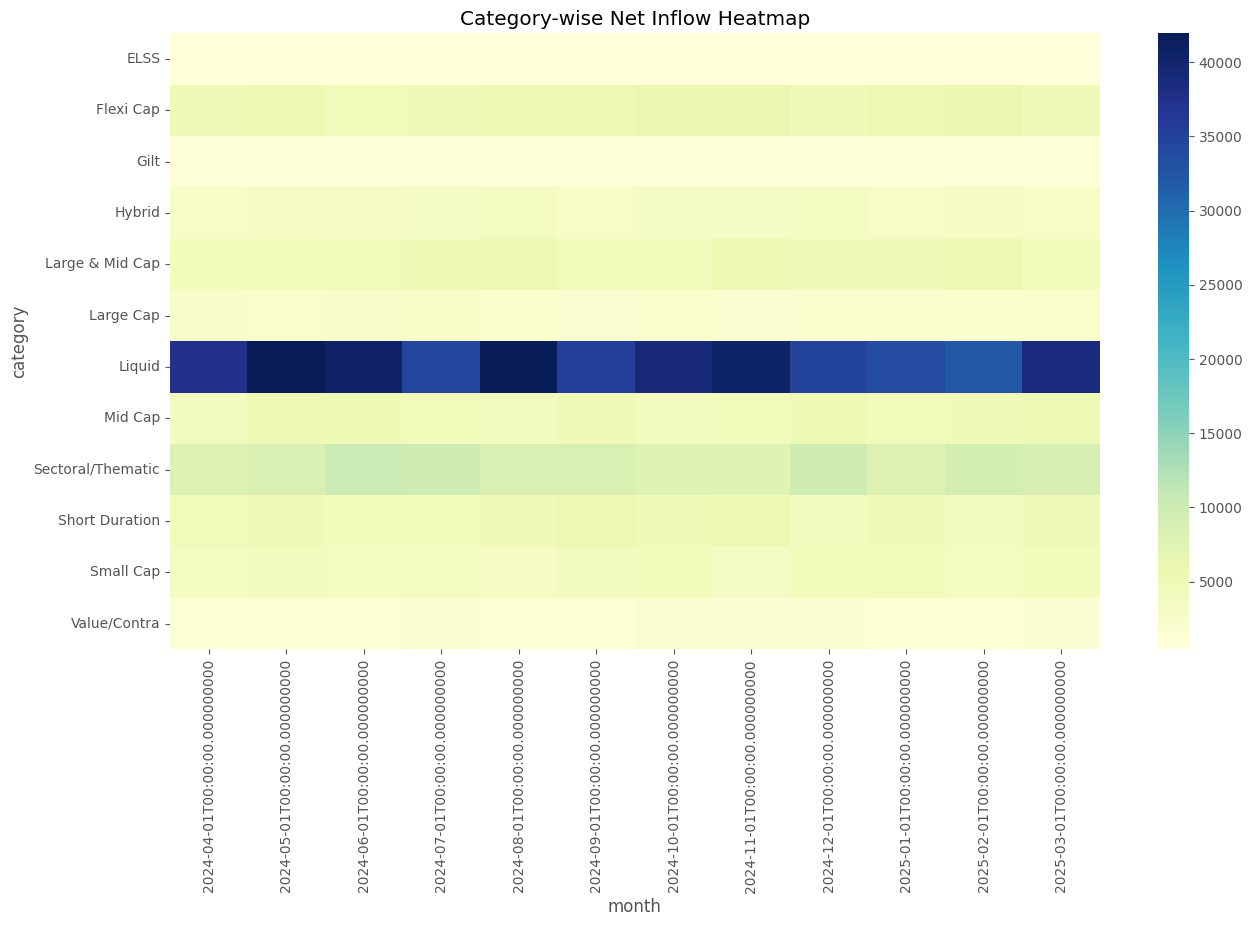

In [15]:
category["month"] = pd.to_datetime(category["month"])

pivot_table = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)
plt.figure(figsize=(15,8))
sns.heatmap(
    pivot_table,
    cmap="YlGnBu",
    annot=False
)
plt.title("Category-wise Net Inflow Heatmap")
plt.show()

# Investor Age Distribution

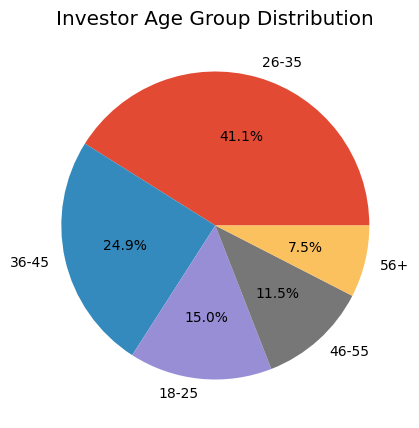

In [16]:
plt.figure(figsize=(8,5))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

# State-wise Investment

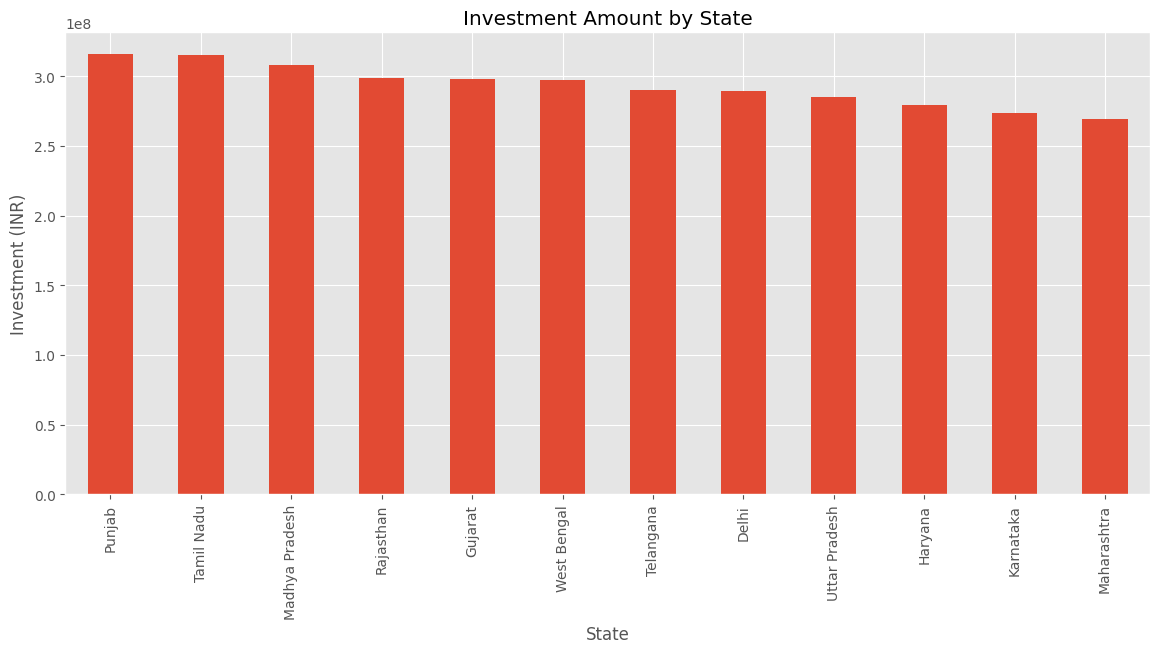

In [17]:
state_amount = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

state_amount.plot(kind="bar")
plt.title("Investment Amount by State")
plt.xlabel("State")
plt.ylabel("Investment (INR)")
plt.xticks(rotation=90)
plt.show()

# Folio Count Growth

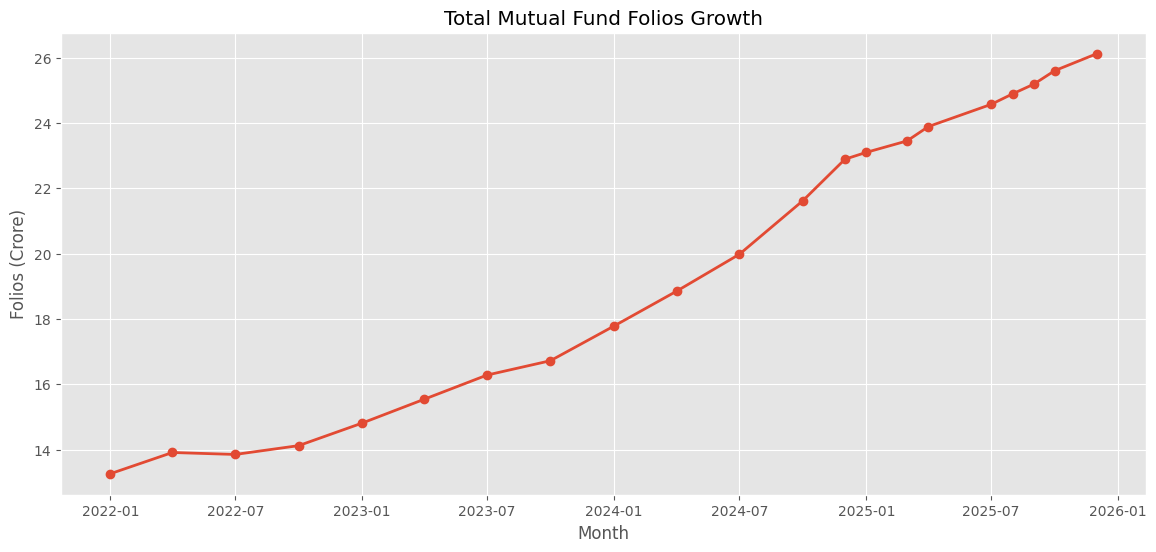

In [18]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Total Mutual Fund Folios Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.grid(True)
plt.show()

# Correlation Matrix

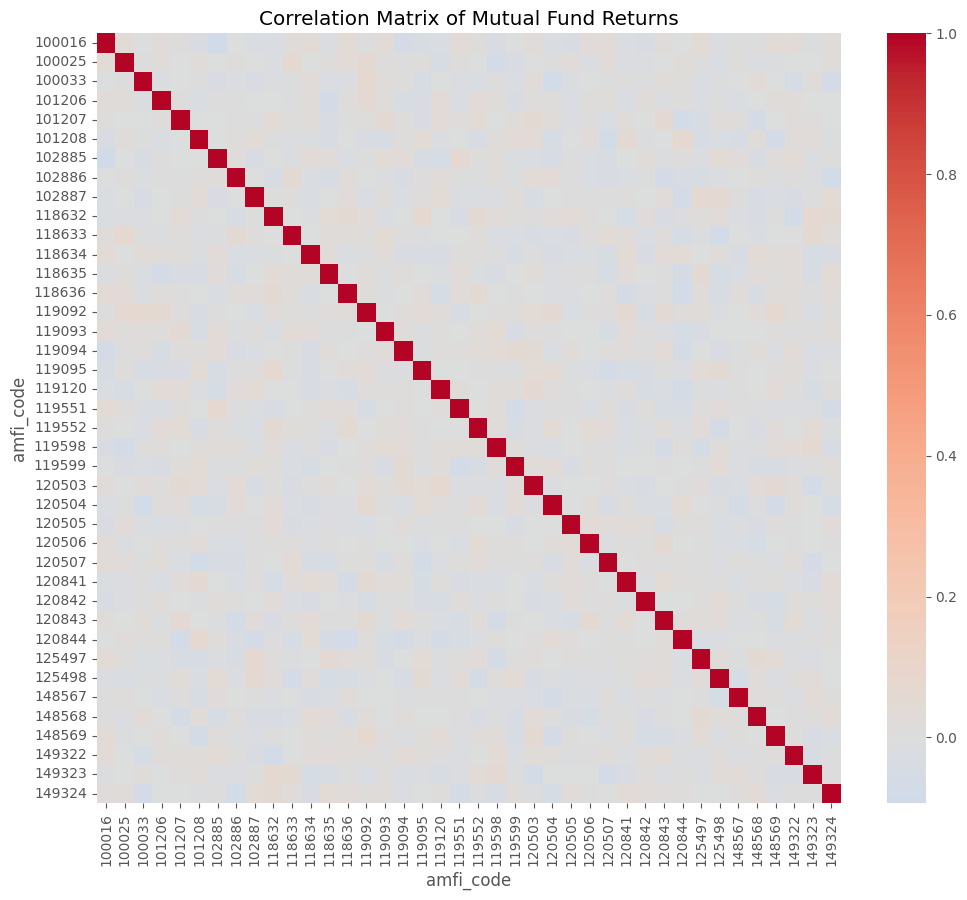

In [19]:
nav_pivot = nav_history.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)
returns = nav_pivot.pct_change()

plt.figure(figsize=(12,10))
sns.heatmap(
    returns.corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Mutual Fund Returns")
plt.show()

# Sector Allocation

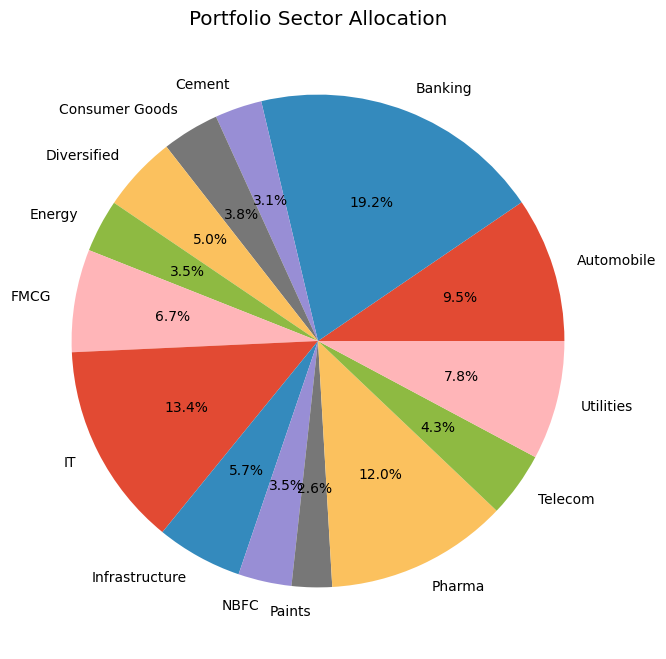

In [20]:
sector = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
)
plt.figure(figsize=(8,8))
plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)
plt.title("Portfolio Sector Allocation")
plt.show()

# Top 10 Fund Houses

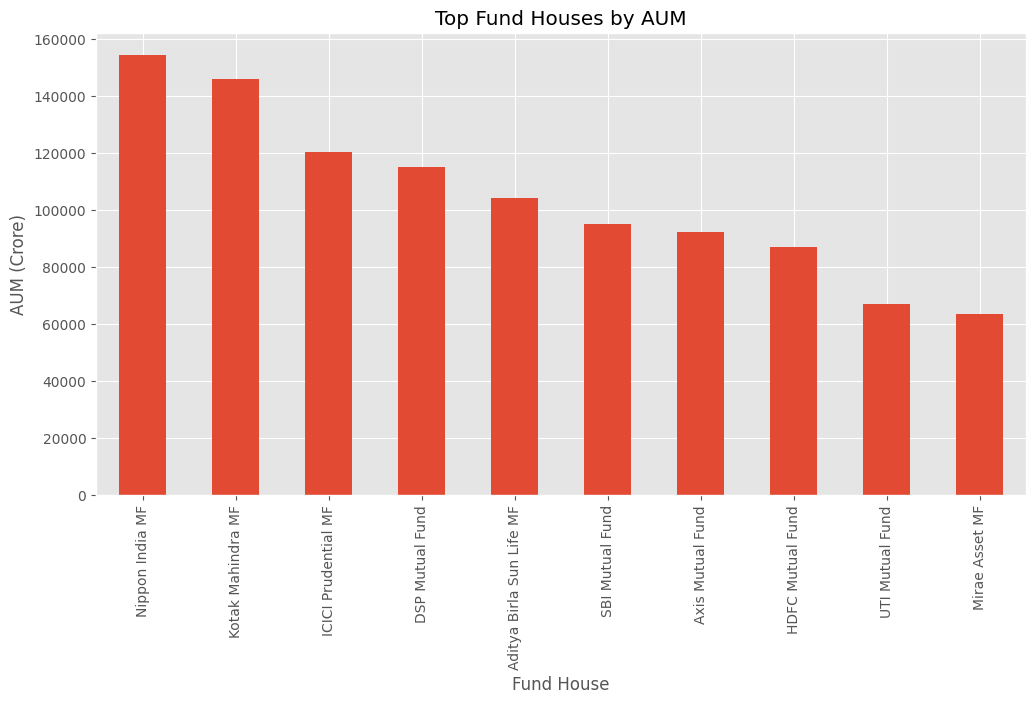

In [21]:
top_fund = (
    performance
    .groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
top_fund.plot(kind="bar")
plt.title("Top Fund Houses by AUM")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=90)
plt.show()

# Key Findings

1. Highest AUM Fund House:
2. Highest NAV Scheme:
3. Highest SIP Inflow Month:
4. Best Performing Category:
5. Highest Investor State:
6. Most Common Transaction Type:
7. Largest Portfolio Sector:
8. Strongest Correlation Observed:
9. Folio Growth Trend:
10. Overall Business Insight: